Mục tiêu: Kiểm định hiệu ứng **KHÔNG đồng nhất** — việc dời gate 30→40 có làm retention D7 thay đổi khác nhau giữa các nhóm engagement (light/medium/heavy) hay không (χ² từng segment + effect size + CI, đọc theo **pattern** chứ không tuyên bố cứng từng ô).

Ngày phân tích: 2026-08-08

**Step 1:** Import thư viện và cố định seed

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
np.random.seed(42)
print('Environment ready.')

Environment ready.


**STEP 2:** Load mart (SQL Server, fallback CSV replicate policy)

**NOTE:** cần cột `engagement_bucket` (tertile p33/p67 trên **TOÀN pop**, Phase 3). Fallback CSV phải tái tạo đúng ngưỡng bucket nếu không so sánh cross-group sẽ lệch.

In [2]:
def load_from_sql():
    import os
    from dotenv import load_dotenv
    import pyodbc
    load_dotenv()
    conn = pyodbc.connect(
        f"DRIVER={{{os.getenv('DB_DRIVER')}}};"
        f"SERVER={os.getenv('DB_SERVER')};DATABASE={os.getenv('DB_NAME')};"
        f"Trusted_Connection={os.getenv('DB_TRUSTED_CONNECTION','yes')};"
    )
    q = ("SELECT userid, version, sum_gamerounds, retention_1, retention_7, "
         "engagement_bucket FROM cookie_cats.mart_ab_test_base")
    return pd.read_sql(q, conn)

def load_from_csv():
    raw = pd.read_csv('../data/cookie_cats.csv')
    m = (raw.groupby('userid')
            .agg(version=('version','max'),
                 sum_gamerounds=('sum_gamerounds','max'),
                 retention_1=('retention_1','max'),
                 retention_7=('retention_7','max'))
            .reset_index())
    m = m[m['sum_gamerounds'] != 49854].copy()          # loai outlier (DEC-03)
    m['retention_1'] = m['retention_1'].astype(int)
    m['retention_7'] = m['retention_7'].astype(int)
    # tai tao engagement_bucket theo tertile p33/p67 tren TOAN pop (Phase 3 policy)
    q33, q67 = m['sum_gamerounds'].quantile([0.33, 0.67])
    m['engagement_bucket'] = np.where(m['sum_gamerounds'] <= q33, 'light',
                             np.where(m['sum_gamerounds'] <= q67, 'medium', 'heavy'))
    return m

try:
    mart = load_from_sql()
    SOURCE = 'SQL Server (cookie_cats.mart_ab_test_base)'
except Exception:
    mart = load_from_csv()
    SOURCE = 'CSV fallback (mart policy replicated in pandas)'

print(f'Source: {SOURCE}')
print(f'Rows: {len(mart):,} | columns: {list(mart.columns)}')
assert len(mart) == 90188, 'Row count khac 90,188 -> kiem tra lai mart policy!'
mart[['version','engagement_bucket','retention_7']].head()

C:\Users\Asus\AppData\Local\Temp\ipykernel_5620\2450915989.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(q, conn)


Source: SQL Server (cookie_cats.mart_ab_test_base)
Rows: 90,188 | columns: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7', 'engagement_bucket']


,version,engagement_bucket,retention_7
0,gate_30,light,0
1,gate_30,heavy,0
2,gate_40,heavy,0
3,gate_40,light,0
4,gate_40,heavy,1


**Step 3:** Khai báo ngưỡng alpha/Bonferroni và hàm verdict

**NOTE:** segment là 1 lát cắt của test D7 (H0₂) -> vẫn đọc dưới ngưỡng Bonferroni 0.0167.

In [3]:
ALPHA, N_TESTS = 0.05, 3
ALPHA_BONF = ALPHA / N_TESTS
def verdict(p):
    if p < ALPHA_BONF: return 'SIGNIFICANT (vuot Bonferroni)'
    if p < ALPHA:      return 'sig o 0.05, KHONG vuot Bonferroni'
    return 'KHONG significant'
print(f'alpha={ALPHA} | Bonferroni={ALPHA_BONF:.4f}')

alpha=0.05 | Bonferroni=0.0167


**STEP 4:** Pivot retention D7 (%) theo `engagement_bucket` × version

**NOTE:** bucket cắt trên TOTAL pop -> ngưỡng light/medium/heavy giống hệt 2 nhóm -> so cross-group hợp lệ.

In [5]:
ORDER = ['light', 'medium', 'heavy']
piv_rate = (mart.pivot_table(index='engagement_bucket', columns='version',
                             values='retention_7', aggfunc='mean')
                .reindex(ORDER) * 100)
piv_n = (mart.pivot_table(index='engagement_bucket', columns='version',
                          values='retention_7', aggfunc='count')
             .reindex(ORDER))
print('Retention D7 (%) theo segment:'); print(piv_rate.round(2))
print('\nSample size mỗi ô:');            print(piv_n)

Retention D7 (%) theo segment:
version            gate_30  gate_40
engagement_bucket                  
light               1.4200   1.5400
medium              8.2500   7.6100
heavy              47.6600  46.3800

Sample size mỗi ô:
version            gate_30  gate_40
engagement_bucket                  
light                14675    15282
medium               15266    15391
heavy                14758    14816


**Step 5:** Chi-square + effect size + CI cho retention_7 TRONG từng segment

**NOTE:** đọc theo PATTERN (hướng + độ lớn diff giữa các bucket), không chỉ nhìn p-value từng ô.

In [6]:
seg_rows = []
for bk in ORDER:
    sub = mart[mart['engagement_bucket'] == bk]
    ct  = pd.crosstab(sub['version'], sub['retention_7'])
    chi2v, pv, dof, expected = stats.chi2_contingency(ct, correction=True)   # Yates cho 2x2
    r30 = sub.loc[sub.version == 'gate_30', 'retention_7'].mean()
    r40 = sub.loc[sub.version == 'gate_40', 'retention_7'].mean()
    n30_s = int((sub.version == 'gate_30').sum())
    n40_s = int((sub.version == 'gate_40').sum())
    diff = r40 - r30
    se   = np.sqrt(r30*(1-r30)/n30_s + r40*(1-r40)/n40_s)
    ci_lo, ci_hi = diff - 1.96*se, diff + 1.96*se
    cohen_h = 2*np.arcsin(np.sqrt(r40)) - 2*np.arcsin(np.sqrt(r30))
    seg_rows.append({
        'segment': bk,
        'gate_30':  f'{r30*100:.2f}%',
        'gate_40':  f'{r40*100:.2f}%',
        'Diff (pp)': f'{diff*100:+.2f}',
        '95% CI (pp)': f'[{ci_lo*100:+.2f}, {ci_hi*100:+.2f}]',
        "Cohen's h": f'{cohen_h:+.4f}',
        'chi2 (Yates)': f'{chi2v:.3f}',
        'p (Yates)': f'{pv:.4f}',
        'min expected': f'{expected.min():,.0f}',
        'Ket luan': verdict(pv),
    })
seg_summary = pd.DataFrame(seg_rows)
seg_summary

,segment,gate_30,gate_40,Diff (pp),95% CI (pp),Cohen's h,chi2 (Yates),p (Yates),min expected,Ket luan
0,light,1.42%,1.54%,+0.11,"[-0.16, +0.39]",+0.0094,0.586,0.4441,218,KHONG significant
1,medium,8.25%,7.61%,-0.63,"[-1.24, -0.03]",-0.0234,4.110,0.0426,"1,211","sig o 0.05, KHONG vuot Bonferroni"
2,heavy,47.66%,46.38%,-1.27,"[-2.41, -0.14]",-0.0255,4.760,0.0291,"6,939","sig o 0.05, KHONG vuot Bonferroni"


**Step 6:** Đọc pattern segment -> đối chiếu checkpoint kỳ vọng

**NOTE:** heterogeneity = diff khác hẳn nhau giữa các bucket. Kỳ vọng: user light rời game trước cả gate 30 -> gần như trơ; user medium/heavy mới chạm gate -> nếu có hại D7 thì rơi vào đây.

In [8]:
diffs_pp = {}
for bk in ORDER:
    r30 = mart.loc[(mart.engagement_bucket == bk) & (mart.version == 'gate_30'), 'retention_7'].mean()
    r40 = mart.loc[(mart.engagement_bucket == bk) & (mart.version == 'gate_40'), 'retention_7'].mean()
    diffs_pp[bk] = (r40 - r30) * 100
print('Diff D7 (pp) theo segment:', {k: round(v, 2) for k, v in diffs_pp.items()})

light_flat = abs(diffs_pp['light']) < 0.5                       # light gan nhu khong doi
heavy_hurt = diffs_pp['medium'] < 0 and diffs_pp['heavy'] < 0   # medium & heavy deu am
print('\nCHECKPOINT:')
print(' - Light khong anh huong :', 'DAT'  if light_flat else 'KHONG nhu ky vong')
print(' - Medium/Heavy bi giam  :', 'DAT'  if heavy_hurt else 'KHONG nhu ky vong')
if light_flat and heavy_hurt:
    print('\n=> Tac hai D7 xuat hien o nhom cham gate (medium/heavy); light roi game truoc gate nen gan như khong anh huong.')
else:
    print('\n=> Pattern lech ky vong -> xem lai phan phoi sum_gamerounds & nguong bucket truoc khi ket luan.')

Diff D7 (pp) theo segment: {'light': np.float64(0.11), 'medium': np.float64(-0.63), 'heavy': np.float64(-1.27)}

CHECKPOINT:
 - Light khong anh huong : DAT
 - Medium/Heavy bi giam  : DAT

=> Tac hai D7 xuat hien o nhom cham gate (medium/heavy); light roi game truoc gate nen gan như khong anh huong.


**Step 7:** Vẽ grouped bar retention D7 theo segment (± 95% CI) và lưu file

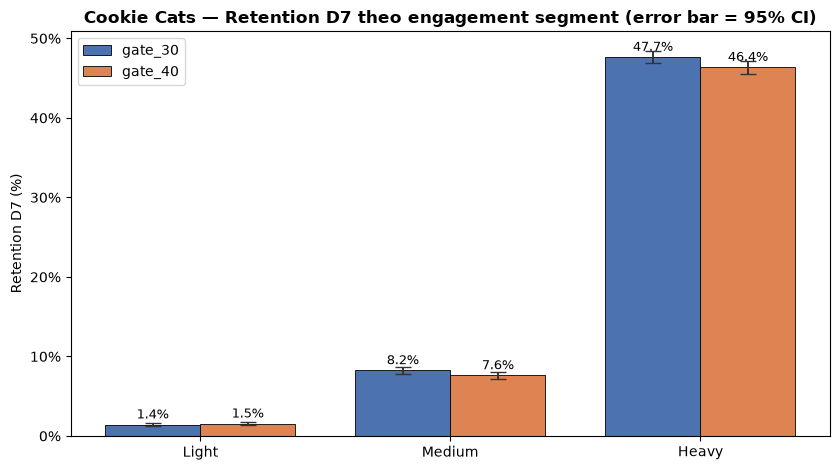

Saved: reports/phase4_g3_segment_d7.png


In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(ORDER)); w = 0.38
err30 = [1.96*np.sqrt((piv_rate.loc[b,'gate_30']/100)*(1-piv_rate.loc[b,'gate_30']/100)
                      / piv_n.loc[b,'gate_30'])*100 for b in ORDER]
err40 = [1.96*np.sqrt((piv_rate.loc[b,'gate_40']/100)*(1-piv_rate.loc[b,'gate_40']/100)
                      / piv_n.loc[b,'gate_40'])*100 for b in ORDER]
b1 = ax.bar(x-w/2, piv_rate['gate_30'], w, yerr=err30, capsize=6,
            label='gate_30', color='#4C72B0', edgecolor='black', linewidth=0.6,
            error_kw=dict(ecolor='#333', lw=1.4))
b2 = ax.bar(x+w/2, piv_rate['gate_40'], w, yerr=err40, capsize=6,
            label='gate_40', color='#DD8452', edgecolor='black', linewidth=0.6,
            error_kw=dict(ecolor='#333', lw=1.4))
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([b.capitalize() for b in ORDER])
ax.set_ylabel('Retention D7 (%)')
ax.set_title('Cookie Cats — Retention D7 theo engagement segment (error bar = 95% CI)',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.legend(); ax.grid(False)
fig.tight_layout()
fig.savefig('../reports/figures/phase4_g3_segment_d7.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: reports/phase4_g3_segment_d7.png')